# **OSEMN: Explore | Exploratory Data Analysis (2019-2023)**
The EDA focuses on understanding the admissions and enrollment patterns, institutional characteristics and key metrics that influence the admissions and enrollment pipelines.

**1. Environment Setup: Mount Drive to Upload in Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Dataset Loading and Structure Review**

In [ ]:
import pandas as pd

#load dataset
df = pd.read_excel('/content/drive/MyDrive/P2 MDS/03_Data_Preprocessing/final_dataset_feature_engineered.xlsx')

#check number of rows and columns
print("Shape of dataset:", df.shape)

Shape of dataset: (276, 52)


**3. Admissions and Enrollment Funnel Analysis**

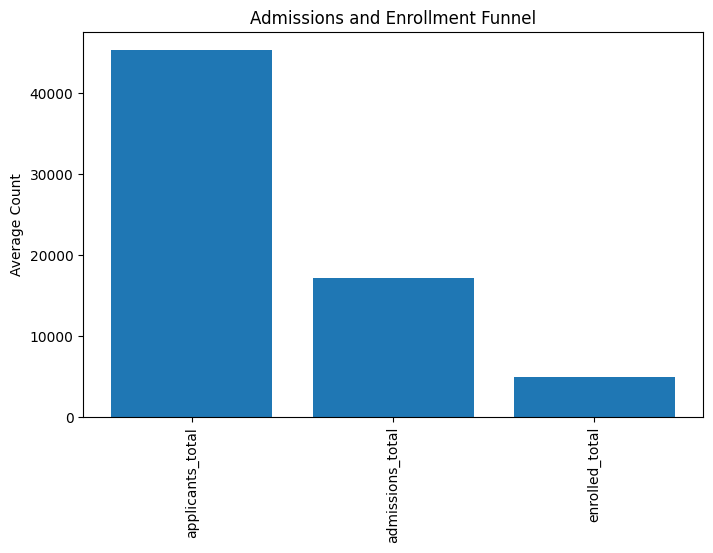

Applicants to Admissions drop-off: 62.03%
Admissions to Enrolled drop-off: 71.30%
Overall Applicants to Enrolled conversion: 10.90%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#average values across dataset
funnel_avg = df[['applicants_total', 'admissions_total', 'enrolled_total']].mean()

#plot
plt.figure(figsize=(8,5))
plt.bar(funnel_avg.index, funnel_avg.values)
plt.title("Admissions and Enrollment Funnel")
plt.ylabel("Average Count")
plt.xticks(rotation=90)
plt.show()

#calculate drop-off percentages
applicants = funnel_avg['applicants_total']
admissions = funnel_avg['admissions_total']
enrolled = funnel_avg['enrolled_total']

drop_app_to_adm = ((applicants - admissions) / applicants) * 100
drop_adm_to_enr = ((admissions - enrolled) / admissions) * 100
overall_conversion = (enrolled / applicants) * 100

print(f"Applicants to Admissions drop-off: {drop_app_to_adm:.2f}%")
print(f"Admissions to Enrolled drop-off: {drop_adm_to_enr:.2f}%")
print(f"Overall Applicants to Enrolled conversion: {overall_conversion:.2f}%")

**4. Trends in Applicants, Admissions and Enrollment**

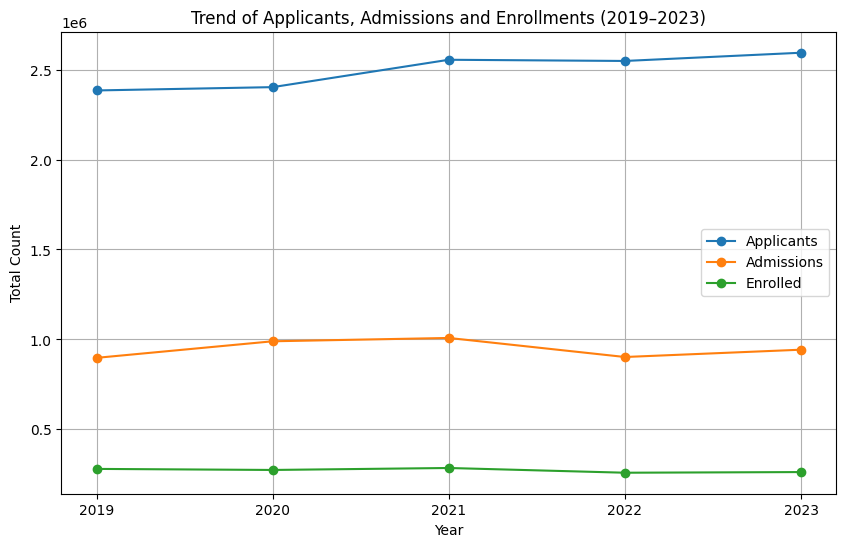

,year,applicants_total,admissions_total,enrolled_total
0,2019,2384213,897486,280009
1,2020,2402608,989591,274171
2,2021,2554799,1008099,285100
3,2022,2548155,902186,258794
4,2023,2593961,942820,262416


,year,applicants_total,admissions_total,enrolled_total,applicants_growth_%,admissions_growth_%,enrolled_growth_%
0,2019,2384213,897486,280009,NaN,NaN,NaN
1,2020,2402608,989591,274171,0.771533,10.262556,-2.084933
2,2021,2554799,1008099,285100,6.334408,1.870268,3.986198
3,2022,2548155,902186,258794,-0.260060,-10.506210,-9.226938
4,2023,2593961,942820,262416,1.797614,4.503949,1.399569


In [ ]:
import matplotlib.pyplot as plt

# aggregate by year (use sum for total pipeline volume)
trend_df = df.groupby('year')[[
    'applicants_total',
    'admissions_total',
    'enrolled_total'
]].sum().reset_index()

# ensure year is integer
trend_df['year'] = trend_df['year'].astype(int)

# plot
plt.figure(figsize=(10,6))

plt.plot(trend_df['year'], trend_df['applicants_total'], marker='o', label='Applicants')
plt.plot(trend_df['year'], trend_df['admissions_total'], marker='o', label='Admissions')
plt.plot(trend_df['year'], trend_df['enrolled_total'], marker='o', label='Enrolled')

plt.title("Trend of Applicants, Admissions and Enrollments (2019–2023)")
plt.xlabel("Year")
plt.ylabel("Total Count")

# fix x-axis
plt.xticks(trend_df['year'])

plt.legend()
plt.grid(True)

plt.show()

# show table
display(trend_df)

trend_df['applicants_growth_%'] = trend_df['applicants_total'].pct_change() * 100
trend_df['admissions_growth_%'] = trend_df['admissions_total'].pct_change() * 100
trend_df['enrolled_growth_%'] = trend_df['enrolled_total'].pct_change() * 100

display(trend_df)

**5. Admissions Rate - Yield Rate - Conversion Rate Distribution**

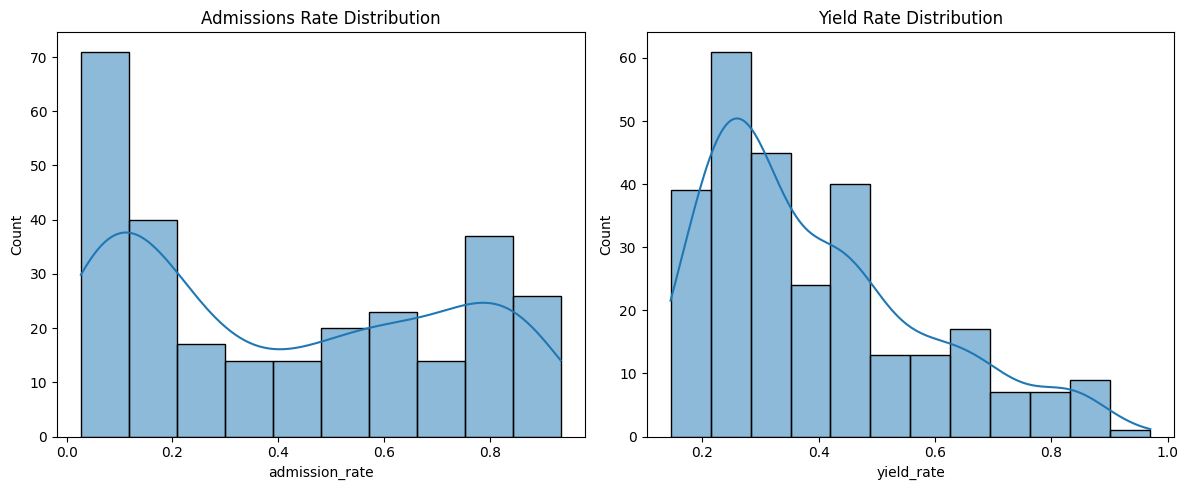

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['admission_rate'], kde=True, ax=axes[0])
axes[0].set_title("Admissions Rate Distribution")

sns.histplot(df['yield_rate'], kde=True, ax=axes[1])
axes[1].set_title("Yield Rate Distribution")

plt.tight_layout()
plt.show()

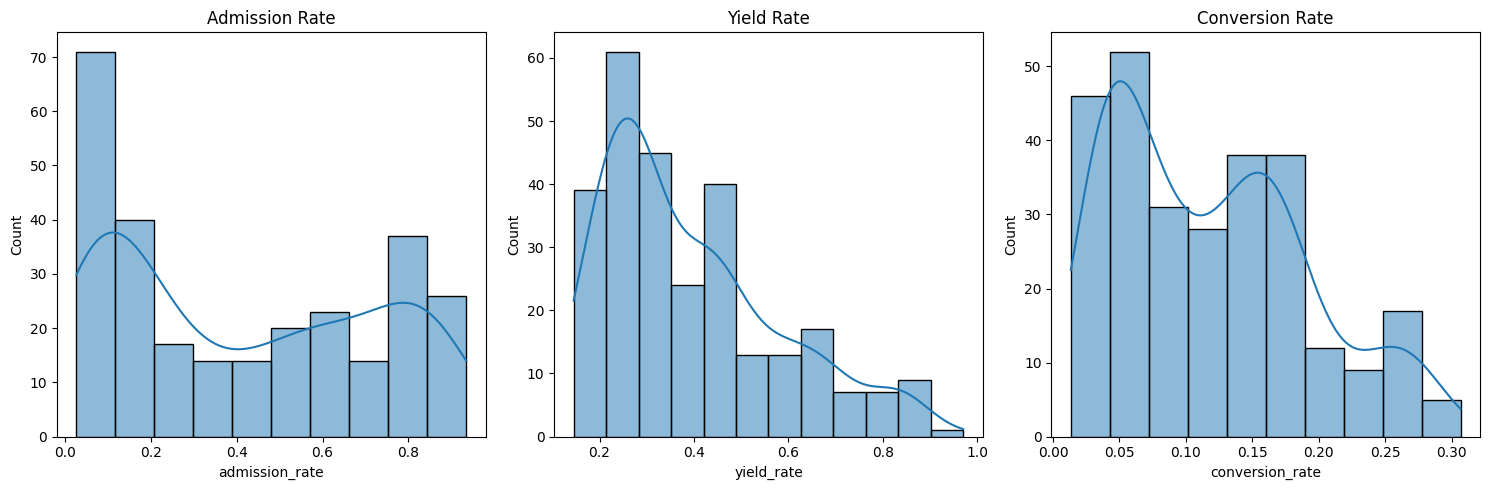

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

#admission Rate
sns.histplot(df['admission_rate'], kde=True, ax=axes[0])
axes[0].set_title("Admission Rate")

#yield Rate
sns.histplot(df['yield_rate'], kde=True, ax=axes[1])
axes[1].set_title("Yield Rate")

#conversion Rate
sns.histplot(df['conversion_rate'], kde=True, ax=axes[2])
axes[2].set_title("Conversion Rate")

plt.tight_layout()
plt.show()

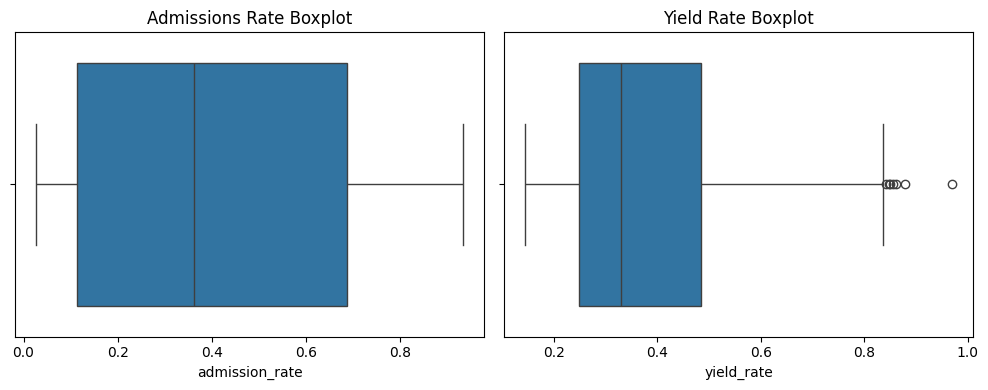

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['admission_rate'])
plt.title("Admissions Rate Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df['yield_rate'])
plt.title("Yield Rate Boxplot")

plt.tight_layout()
plt.show()

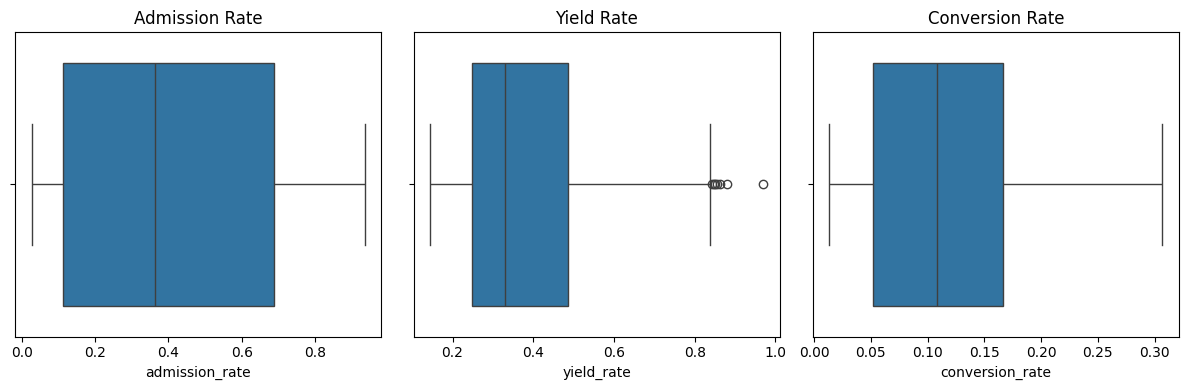

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(x=df['admission_rate'])
plt.title("Admission Rate")

plt.subplot(1,3,2)
sns.boxplot(x=df['yield_rate'])
plt.title("Yield Rate")

plt.subplot(1,3,3)
sns.boxplot(x=df['conversion_rate'])
plt.title("Conversion Rate")

plt.tight_layout()
plt.show()

In [ ]:
summary = df[['admission_rate', 'yield_rate', 'conversion_rate']].describe().T
display(summary)

,count,mean,std,min,25%,50%,75%,max
admission_rate,276.0,0.411614,0.303953,0.026946,0.113770,0.363380,0.686865,0.934248
yield_rate,276.0,0.394312,0.187263,0.145189,0.247945,0.330408,0.485152,0.970183
conversion_rate,276.0,0.118769,0.072849,0.013473,0.051691,0.108021,0.166840,0.306752


**6. Admissions Rate - Yield Rate - Conversion Rate Relationship**

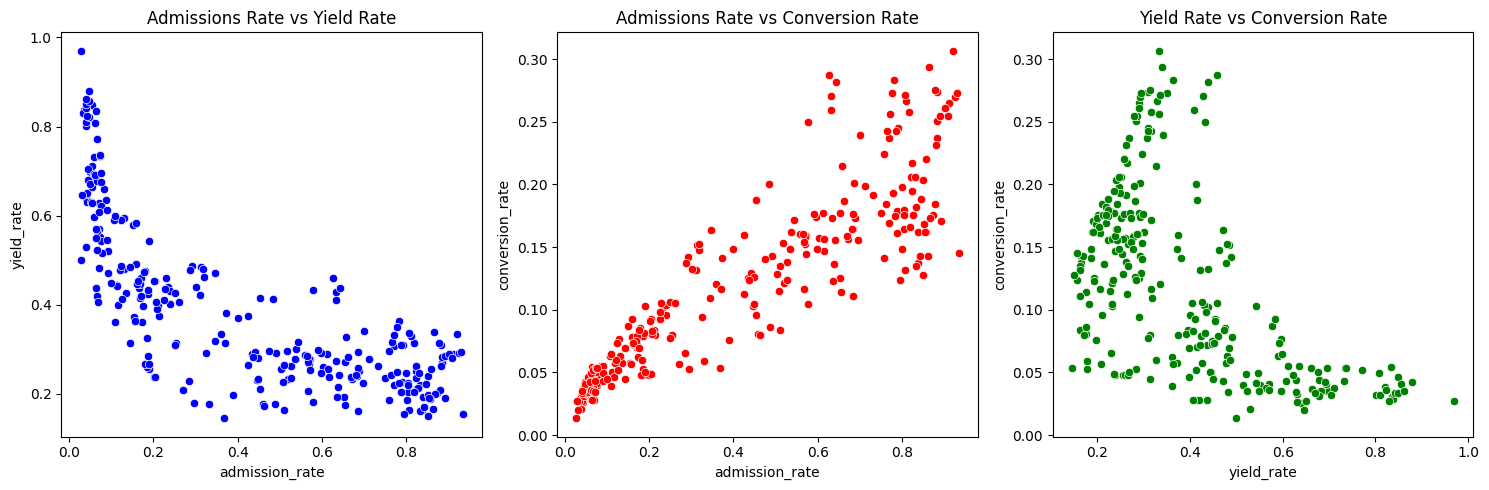

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

#Admission vs Yield
sns.scatterplot(data=df, x='admission_rate', y='yield_rate', ax=axes[0], color='blue')
axes[0].set_title("Admissions Rate vs Yield Rate")

#Admission vs Conversion
sns.scatterplot(data=df, x='admission_rate', y='conversion_rate', ax=axes[1], color='red')
axes[1].set_title("Admissions Rate vs Conversion Rate")

#Yield vs Conversion
sns.scatterplot(data=df, x='yield_rate', y='conversion_rate', ax=axes[2], color='green')
axes[2].set_title("Yield Rate vs Conversion Rate")

plt.tight_layout()
plt.show()

**7. Analysis of Engineered Feature**

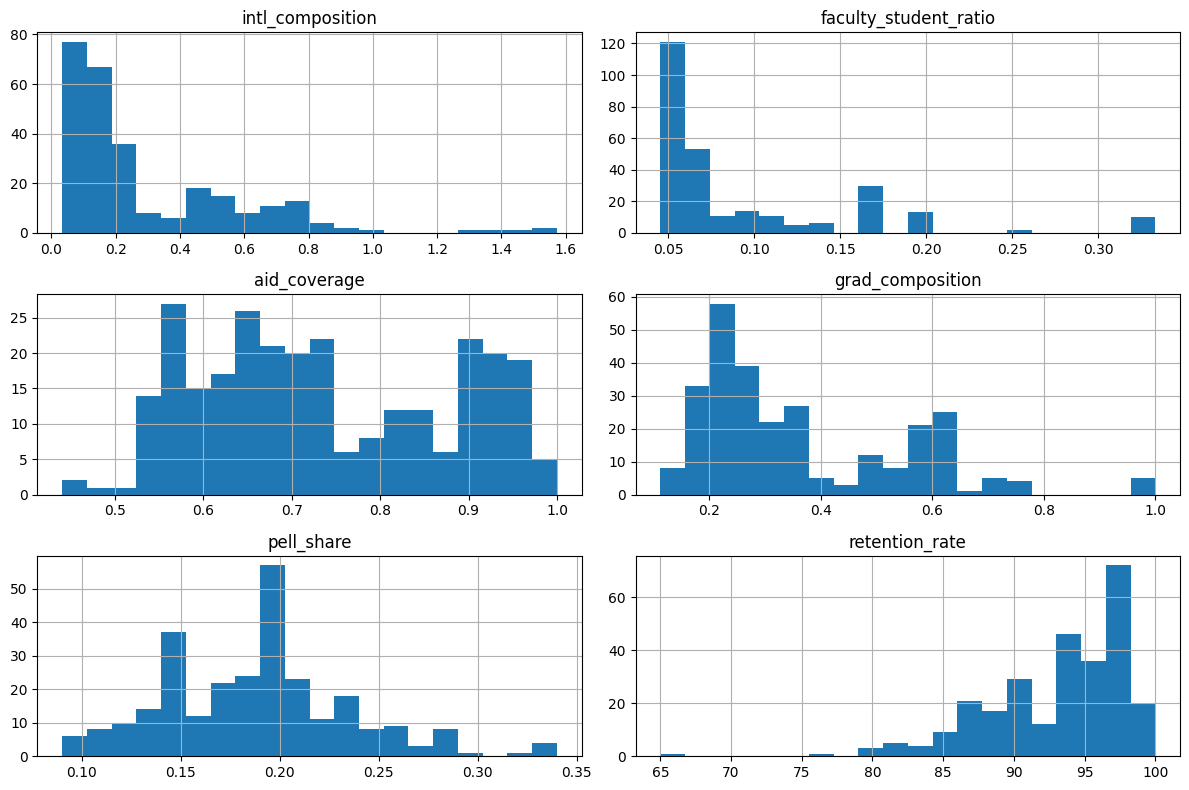

In [ ]:
features = [
    'intl_composition',
    'faculty_student_ratio',
    'aid_coverage',
    'grad_composition',
    'pell_share',
    'retention_rate'
]

df[features].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

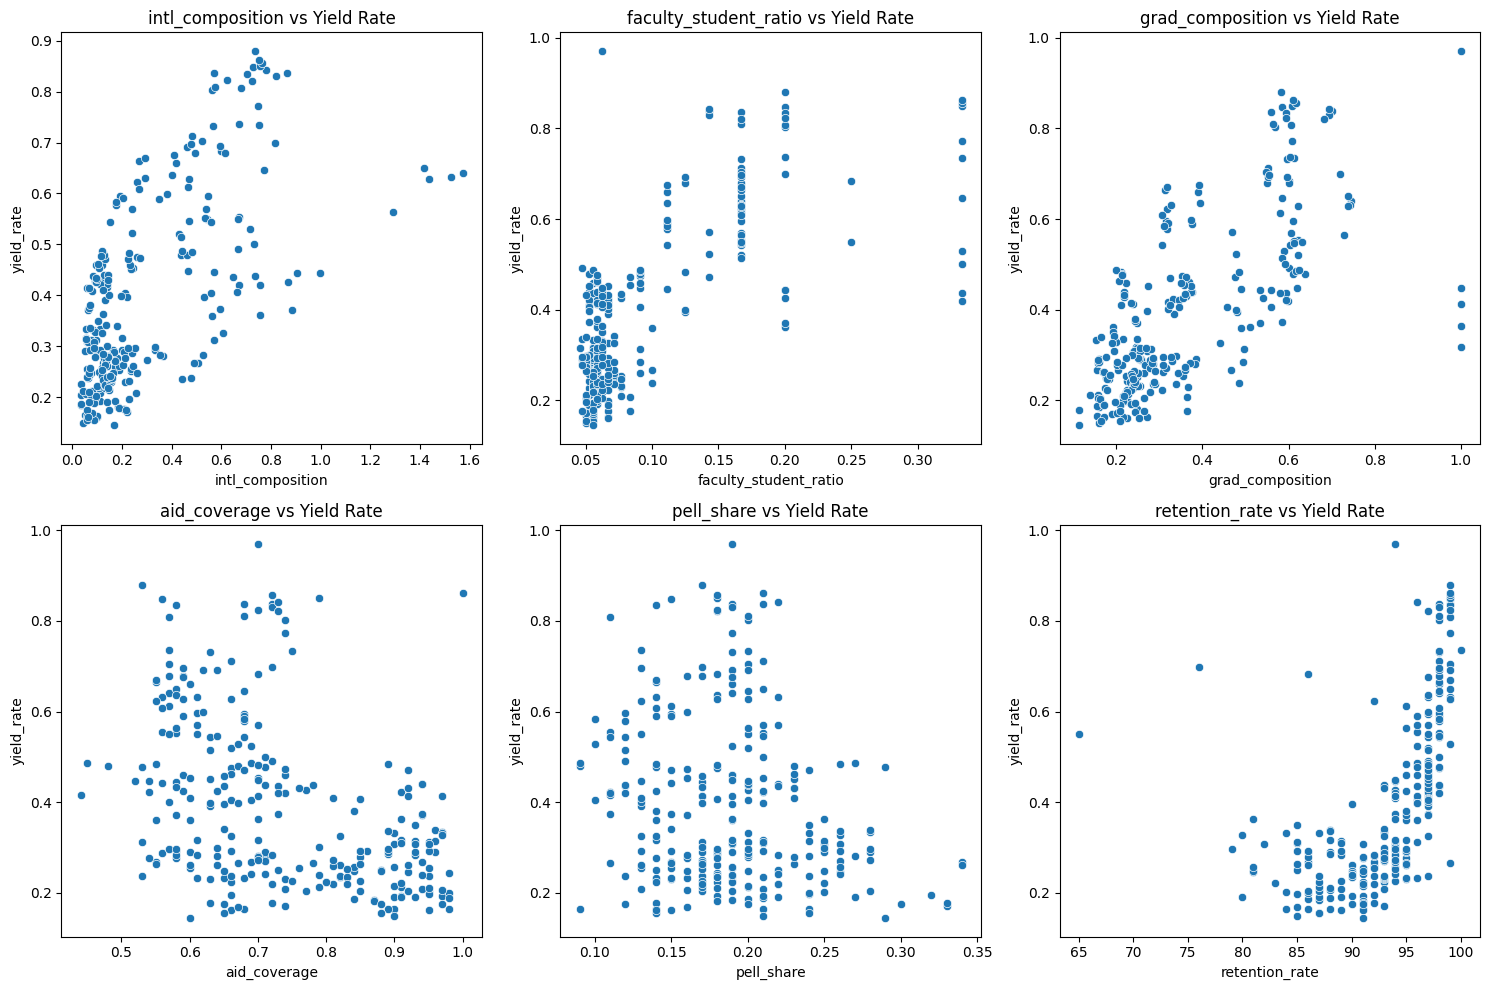

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'intl_composition',
    'faculty_student_ratio',
    'grad_composition',
    'aid_coverage',
    'pell_share',
    'retention_rate'
]

fig, axes = plt.subplots(2, 3, figsize=(15,10))

for i, col in enumerate(features):
    row = i // 3
    col_idx = i % 3

    sns.scatterplot(data=df, x=col, y='yield_rate', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f"{col} vs Yield Rate")

plt.tight_layout()
plt.show()

**8. Correlation Heatmap**

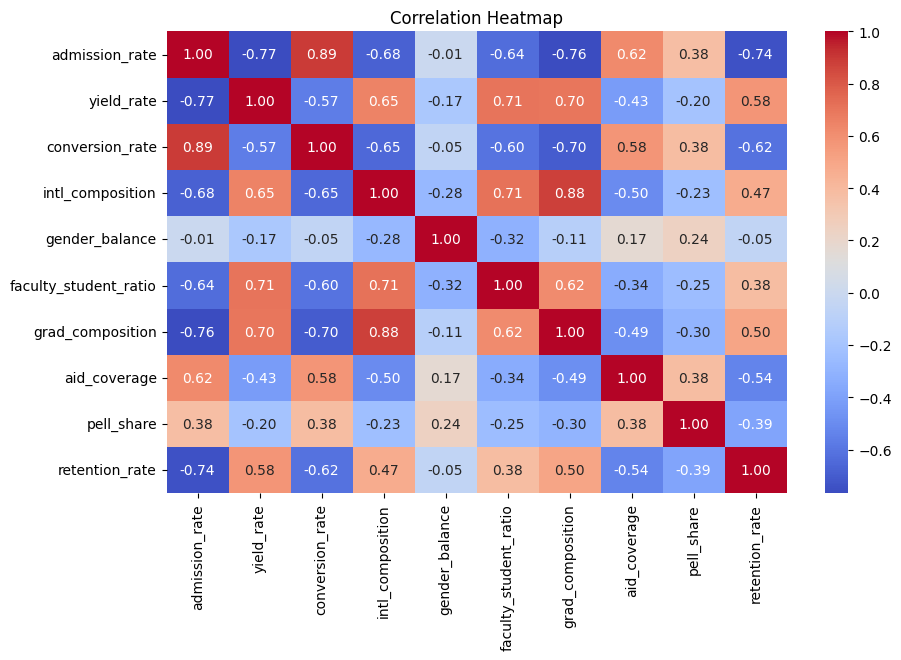

In [ ]:
corr_cols = [
    'admission_rate',
    'yield_rate',
    'conversion_rate',
    'intl_composition',
    'gender_balance',
    'faculty_student_ratio',
    'grad_composition',
    'aid_coverage',
    'pell_share',
    'retention_rate'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

**9. Top vs Bottom Universities**

In [ ]:
top_universities = model_df.groupby('institution_name')['conversion_rate'].mean().sort_values(ascending=False).head(10)

top_universities

,conversion_rate
institution_name,
Texas A & M University-College Station,0.269757
University of Kansas,0.269221
Iowa State University,0.267651
University of Nebraska-Lincoln,0.264362
University of Missouri-Columbia,0.250799
Arizona State University Campus Immersion,0.237419
Washington State University,0.202102
Indiana University-Bloomington,0.189437
Oregon State University,0.186206


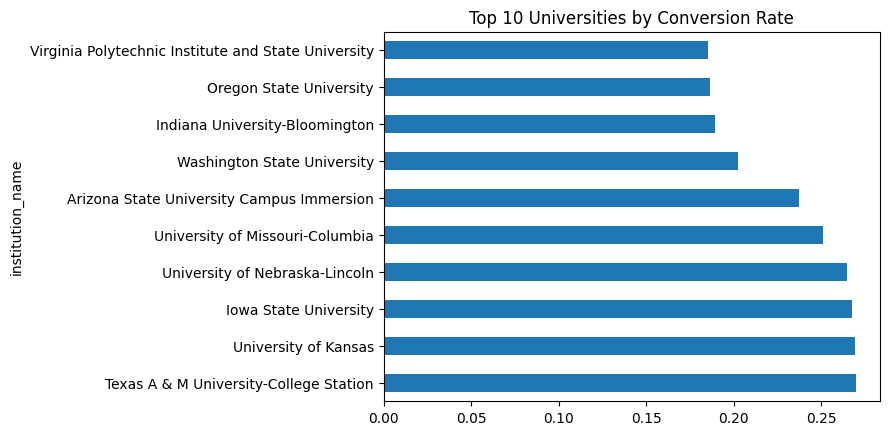

In [ ]:
top_universities.plot(kind='barh')
plt.title('Top 10 Universities by Conversion Rate')
plt.show()